In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
import numpy as np

In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [3]:
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [4]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [5]:
model = models.mobilenet_v2(weights = models.MobileNet_V2_Weights.DEFAULT)

for param in model.features.parameters():
    param.requires_grad = False

In [6]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [7]:
model.classifier[1] = nn.Linear(
    model.last_channel,
    10
)

In [8]:
model = model.to(device)

In [9]:
loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.classifier[1].parameters(),
    lr=0.001
)

In [10]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0

    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = loss_func(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predicted = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Loss: {running_loss / len(train_loader):.4f} "
        f"Accuracy: {accuracy:.2f}%"
    )

Epoch [1/5] Loss: 0.5823 Accuracy: 86.22%
Epoch [2/5] Loss: 0.2902 Accuracy: 91.83%
Epoch [3/5] Loss: 0.2457 Accuracy: 92.72%
Epoch [4/5] Loss: 0.2269 Accuracy: 93.02%
Epoch [5/5] Loss: 0.2169 Accuracy: 93.27%


In [11]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 94.79%


In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt



all_labels = []
all_predictions = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.cpu().numpy())

In [13]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

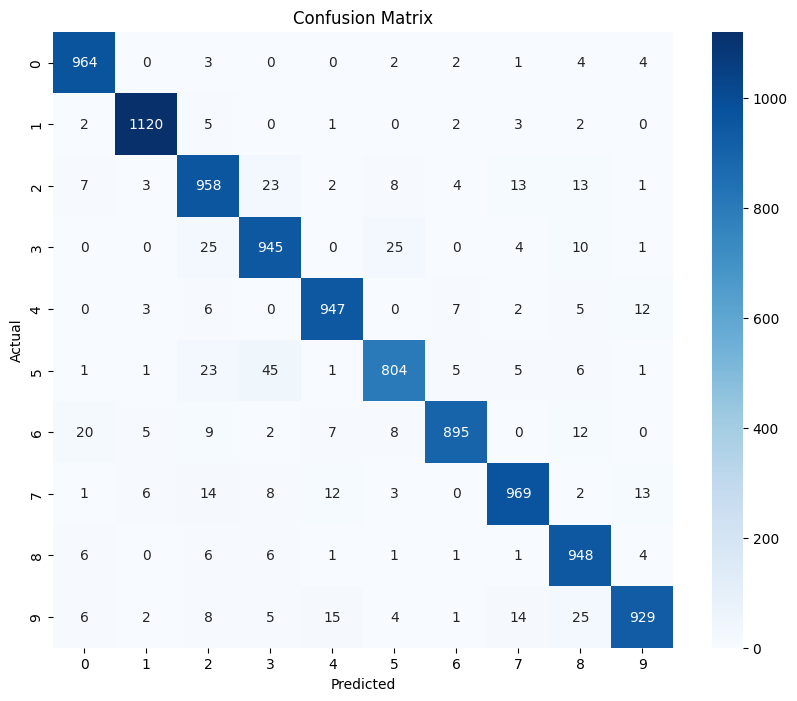

In [14]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [15]:
import matplotlib.pyplot as plt

images, labels = next(iter(test_loader))

model.eval()

with torch.no_grad():

    outputs = model(
        images.to(device)
    )

predictions = torch.argmax(
    outputs,
    dim=1
)

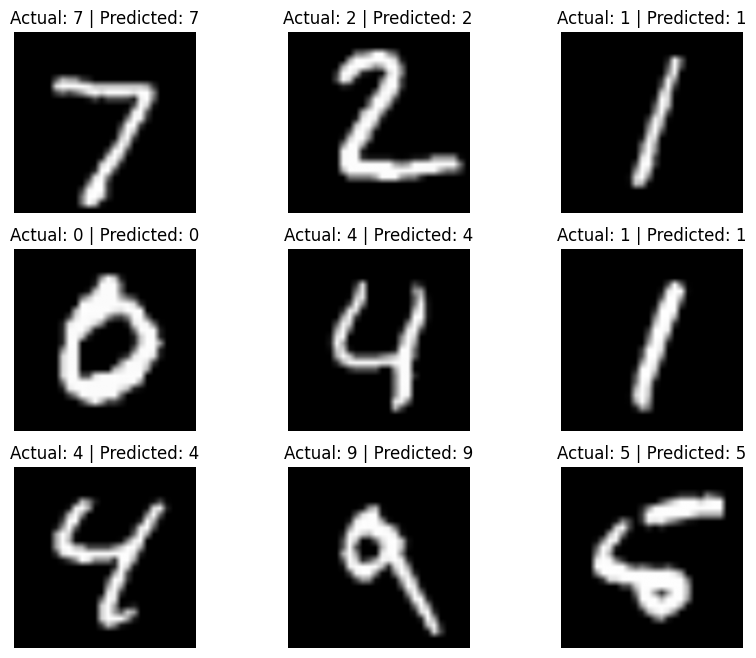

In [16]:
plt.figure(figsize=(10, 8))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    plt.imshow(
        images[i][0],
        cmap="gray"
    )

    plt.title(
        f"Actual: {labels[i].item()} | "
        f"Predicted: {predictions[i].item()}"
    )

    plt.axis("off")

plt.show()